# Predicting pairwise interactions from genomes — 20260630

**Question.** Given only the gene content of two strains, can we predict how they split a well
when grown together?

Labels come from `relative_abundance`'s `r03_pair_replicate_stats.csv` (target:
`mean_log2_ratio_a_over_b`, antisymmetric under swapping the two strains). Features come from
`final_genomic_tables/KEGG_ko_and_strains_table.csv` (KO presence/absence per genome).

All logic lives in `shared_pipelines/genomic_ml.py`; this notebook is the report. Re-runs top
to bottom. `run_genomic_ml.py` does the same thing headless.

Two facts drive every design decision downstream, and both are established before any model is
fit:

1. **Only 20260630 can be used.** The strain-ID join has to be *earned*, not assumed — see §1.
2. **n is 74 genomes, not ~1000 pairs.** The pairs are all the combinations of 74 genomes, so a
   model can score beautifully on held-out *pairs* by memorising per-strain competitiveness.
   Everything is therefore evaluated twice, under `cv_pair` and `cv_strain` — see §4.

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent))                        # config.py
sys.path.insert(0, str(HERE.parents[3] / "shared_pipelines"))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from config import CFG
import genomic_ml as gm

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

gcfg = gm.GenomicMLConfig(exp_cfg=CFG)
gcfg.out_dir

PosixPath('/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/genomic_ml/outputs')

## 1. The strain-ID join, and why it disqualifies 20260721

The genomic tables key strains by a 384-well **source collection**
(`mapping_384_well_plate_collection.csv`); the pairwise experiments key strains by **their own
plate wells**. The labels look alike (`C14`, `G8`, …) and are *not* the same namespace — the
same failure mode that already cost this project once with `corroborated_db.fasta`.

Two independent checks:

**(a) Do the two experiments even agree with each other?** They share 18 well labels. Comparing
each experiment's own 16S consensus for those labels: **only 3 of 18 are the same organism**
(≤15 bp). So 20260721 and 20260630 do not share a namespace, and at most one of them can match
the genomic collection.

**(b) Does the join produce the *right* genomes?** Test something the labels cannot fake: two
strains with near-identical 16S must have near-identical gene content. So 16S divergence
(`ref_pair_bp_dist`, from this experiment's own reads) should track KO-profile divergence
(Jaccard, from the joined genomes). Null = permute the well→genome assignment.

|            | Spearman ρ | z vs. null | 16S ≤5 bp → KO Jaccard | 16S >100 bp → KO Jaccard | verdict |
|------------|-----------|-----------|------------------------|--------------------------|---------|
| `20260630` | **+0.363** | **+6.0** | 0.024 (same genome) | 0.569 | **PASS** |
| `20260721` | −0.046 | −0.7 | 0.613 | 0.589 | **FAIL** |

20260721 is flat across every 16S bin — indistinguishable from assigning genomes to wells at
random. Its well labels belong to a different physical collection and no mapping exists to
recover them, so it is **excluded** rather than joined on a name match. That halves the
available data, and is the correct trade.

In [2]:
val, join_ok = gm.validate_strain_join(gcfg)
print("VERDICT:", "PASS" if join_ok else "FAIL")
assert join_ok, "refusing to model on an unvalidated strain join"
val

VERDICT: PASS


,metric,value,n
0,median_ko_jaccard__16S<=5bp,0.024092,60.0
1,median_ko_jaccard__16S 6-50bp,0.233195,637.0
2,median_ko_jaccard__16S 51-100bp,NaN,0.0
3,median_ko_jaccard__16S>100bp,0.569275,817.0
4,n_pairs_joinable,1582.000000,1677.0
5,spearman_bpdist_vs_kojaccard,0.363399,1582.0
6,permutation_null_mean,0.001430,200.0
7,permutation_null_sd,0.060314,200.0
8,z_vs_permutation_null,6.001376,200.0
9,join_verdict_pass,1.000000,NaN


## 2. The modeling dataset

The filter that matters most is `high_uncertainty_pair`: those are pairs whose two 16S
references are too similar to tell apart, so the reported ≈50/50 is the *assay's resolution
limit*, not a coexistence result. Keeping them would teach the model "similar genomes → 50/50",
an artifact of the measurement. It costs ~37% of the rows.

In [3]:
pairs, summary = gm.build_dataset(gcfg)
display(summary)

X, summ = gm.strain_feature_matrix(gcfg, pairs)
print(f"feature matrix: {X.shape[0]} strains x {X.shape[1]} prevalence-filtered KOs")
print(f"labels: {len(pairs)} pairs, log2-ratio sd = {pairs[gcfg.target].std():.2f}")

phylo = gm.phylo_distance_matrix(gcfg, pairs)     # 16S distances, for the taxonomy control
phylo.shape

,step,n_pairs
0,r03_pairs_total,1677.0
1,after_well_to_genome_join,1677.0
2,after_dropping_genomes_without_annotation,1582.0
3,after_dropping_high_uncertainty_pairs,996.0
4,after_dropping_unstable_replicates,987.0
5,n_strains_final,74.0
6,n_possible_pairs,2701.0
7,pct_of_possible_pairs_tested,36.5
8,n_genomes_dropped_all_zero_ko,6.0


feature matrix: 74 strains x 4739 prevalence-filtered KOs
labels: 987 pairs, log2-ratio sd = 3.70


(74, 74)

### How good could any model be? The label-noise ceiling

An R² of 0.3 means something very different if the labels themselves only reproduce to 0.4.
Wells here carry a median of ~39 reads, so a 55/45 split is simply not resolvable, and the
variance of `log2(p/(1-p))` blows up exactly where this target lives.

In [4]:
ceiling = gm.label_noise_ceiling(gcfg, pairs)
ceiling

,estimator,n,sigma2_noise,var_label,ceiling_r2
0,replicate_spread,146,0.310024,13.641368,0.977273
1,binomial_read_depth,987,1.316231,13.641368,0.903512


## 3. Feature engineering: build the symmetry in, don't hope for it

Which strain is "a" is arbitrary, and the target negates when you swap them. Rather than
leaving a model to infer that, it is imposed three ways:

- features split into an **antisymmetric block** (`x_a − x_b`, "who has which genes") and a
  **symmetric block** (`x_a + x_b`, plus 16S distance — "what kind of pair is this at all");
- training rows carry **both orientations**, labels negated for the reversed copy (the
  augmentation suggested at the outset — it helps, and is kept);
- predictions are **antisymmetrised**: `ŷ = (f(a,b) − f(b,a)) / 2`, which makes the output
  exactly antisymmetric for *any* model, at no cost.

The one trap in the augmentation: both orientations of a pair **must land in the same CV fold**,
or the model sees the test label with its inputs swapped — total leakage. `make_folds` groups on
the unordered pair id for exactly this reason.

PCA (and every scaler) is fit **inside each fold on training strains only**.

## 4. Two evaluation regimes — only one of them is a real test

| regime | held out | question | per-strain lookup available? |
|---|---|---|---|
| `cv_pair` | pairs | *"fill in the ~64% of pairs never tested in a collection we already characterised"* | **yes** — inflates everything |
| `cv_strain` | strains (test pairs have **both** strains unseen) | *"sequence a new isolate; predict how it does against another new isolate"* | **no** — undefined by construction |

`cv_pair` lets a model learn a strain's competitiveness from that strain's *other* pairs, so a
high score there does **not** show that gene content predicts interactions. `cv_strain` drops
pairs straddling the split entirely, and is the honest test.

Controls run alongside every model:

- `zero_baseline` — predict "no winner". R² is defined against this.
- `strength_observed_no_genomics` — per-strain strength refit **in-fold** from training pairs, no
  genomics at all. Under `cv_pair` this is the model to beat; under `cv_strain` it necessarily
  collapses to zero, and that collapse is the point. (The published `r05_bt_strengths.csv` is fit
  on *all* pairs, so using it inside CV would leak the answer — hence the in-fold refit.)
- `ridge_phylo16s_only` / `two_stage_ridge_phylo16s_only` — the strain described only by its 16S
  position. KO content and 16S are both largely phylogenetic, so **whatever KO buys over this row
  is the part that is about gene content rather than taxonomy**.
- `SHUFFLED_*` — labels permuted within the training set. The empirical zero.

In [5]:
models = [m for m in gm.MODELS if "tabpfn" not in m]
summ_df, fold_df, pair_df = gm.cross_validate(
    gcfg, pairs, X, summ, models=models, phylo=phylo, n_repeats=3)

cols = ["regime", "model", "n_test", "r2_mean", "r2_sd", "spearman_rho_mean",
        "sign_accuracy_mean", "mae_mean"]
summ_df[cols].round(3)

,regime,model,n_test,r2_mean,r2_sd,spearman_rho_mean,sign_accuracy_mean,mae_mean
11,cv_pair,xgboost_raw_ko,2961,0.833,0.033,0.922,0.972,1.053
5,cv_pair,strength_observed_no_genomics,2961,0.796,0.026,0.909,0.957,1.256
9,cv_pair,two_stage_xgboost,2961,0.786,0.024,0.908,0.962,1.282
7,cv_pair,two_stage_ridge_ko_plus_phylo,2961,0.687,0.025,0.884,0.951,1.581
4,cv_pair,ridge_phylo16s_only,2961,0.682,0.039,0.854,0.937,1.607
8,cv_pair,two_stage_ridge_phylo16s_only,2961,0.603,0.028,0.847,0.936,1.807
10,cv_pair,xgboost_pca,2961,0.601,0.049,0.783,0.905,1.605
3,cv_pair,ridge_pca,2961,0.576,0.053,0.777,0.899,1.741
6,cv_pair,two_stage_ridge,2961,0.525,0.042,0.775,0.904,1.911
12,cv_pair,zero_baseline,2961,0.000,0.000,NaN,NaN,3.002


### TabPFN

TabPFN is a good fit on paper — it is built for exactly this regime (small-n, tabular). It runs
as its own pass because it is **the one step that sends data off this machine**: fold features
and labels go to the hosted API. The token is read from `$TABPFN_TOKEN` or the mode-600
`.tabpfn_token` beside this notebook, never from the source.

In [6]:
tf_summ, tf_fold, tf_pair = gm.cross_validate(
    gcfg, pairs, X, summ, models=["tabpfn", "two_stage_tabpfn"],
    phylo=phylo, n_repeats=1, shuffle_control=False, file_prefix="g03tabpfn")

fold_df = pd.concat([fold_df, tf_fold], ignore_index=True)
pair_df = pd.concat([pair_df, tf_pair], ignore_index=True)
summ_df = gm.summarize_folds(fold_df)
summ_df.to_csv(gcfg.out_dir / "g03_cv_summary.csv", index=False)
summ_df[cols].round(3)

00:00 Fitting... -

Train set already exists, skipping upload.


00:00 Fitting... \

00:00 Fitting... |

00:00 Fitting... /

...

00:01 Predicting... \

00:01 Predicting... |

00:01 Predicting... /

00:01 Predicting... Done!


,regime,model,n_test,r2_mean,r2_sd,spearman_rho_mean,sign_accuracy_mean,mae_mean
13,cv_pair,xgboost_raw_ko,2961,0.833,0.033,0.922,0.972,1.053
5,cv_pair,strength_observed_no_genomics,2961,0.796,0.026,0.909,0.957,1.256
11,cv_pair,two_stage_xgboost,2961,0.786,0.024,0.908,0.962,1.282
6,cv_pair,tabpfn,987,0.696,0.088,0.842,0.922,1.311
8,cv_pair,two_stage_ridge_ko_plus_phylo,2961,0.687,0.025,0.884,0.951,1.581
4,cv_pair,ridge_phylo16s_only,2961,0.682,0.039,0.854,0.937,1.607
9,cv_pair,two_stage_ridge_phylo16s_only,2961,0.603,0.028,0.847,0.936,1.807
12,cv_pair,xgboost_pca,2961,0.601,0.049,0.783,0.905,1.605
10,cv_pair,two_stage_tabpfn,987,0.589,0.063,0.801,0.909,1.688
3,cv_pair,ridge_pca,2961,0.576,0.053,0.777,0.899,1.741


## 5. Genome → per-strain competitiveness

The two-stage model's first half, examined on its own terms, and the cleanest form of the
scientific question: **74 rows, one target, no pair structure to inflate anything.** Strength is
refit in-fold from training pairs; the genome of a completely held-out strain must predict it.

This is also where the KO-vs-taxonomy comparison is at its fairest, since both representations
face the identical regression problem.

In [7]:
sdf, smet, ko_df = gm.genome_to_strength(gcfg, pairs, X, summ, phylo=phylo)
display(smet.round(3))
ko_df.head(15)

,feature_source,n,r2,mae,n_sign_evaluated,pearson_r,spearman_rho,sign_accuracy
0,ko_content,74,0.408,1.338,74,0.643,0.631,0.865
1,phylo16s_only,74,0.110,1.630,74,0.521,0.506,0.838
2,ko_plus_phylo16s,74,0.327,1.469,74,0.624,0.566,0.851


,ko,spearman_vs_strength,prevalence
3109,K03712,0.701136,47.0
2636,K15852,0.693095,48.0
3129,K13938,0.682493,48.0
3108,K03805,0.679792,50.0
340,K08156,0.675726,46.0
2899,K21089,0.672639,44.0
2999,K12943,0.668980,50.0
3169,K11732,0.668980,50.0
3130,K02442,0.666383,51.0
3101,K00137,0.663940,48.0


The top KOs are **descriptive only** — not cross-validated, and because KO content tracks
phylogeny they largely mark clades rather than mechanisms. Read them as "which lineages are
strong", not "these genes cause dominance".

## 6. Figures

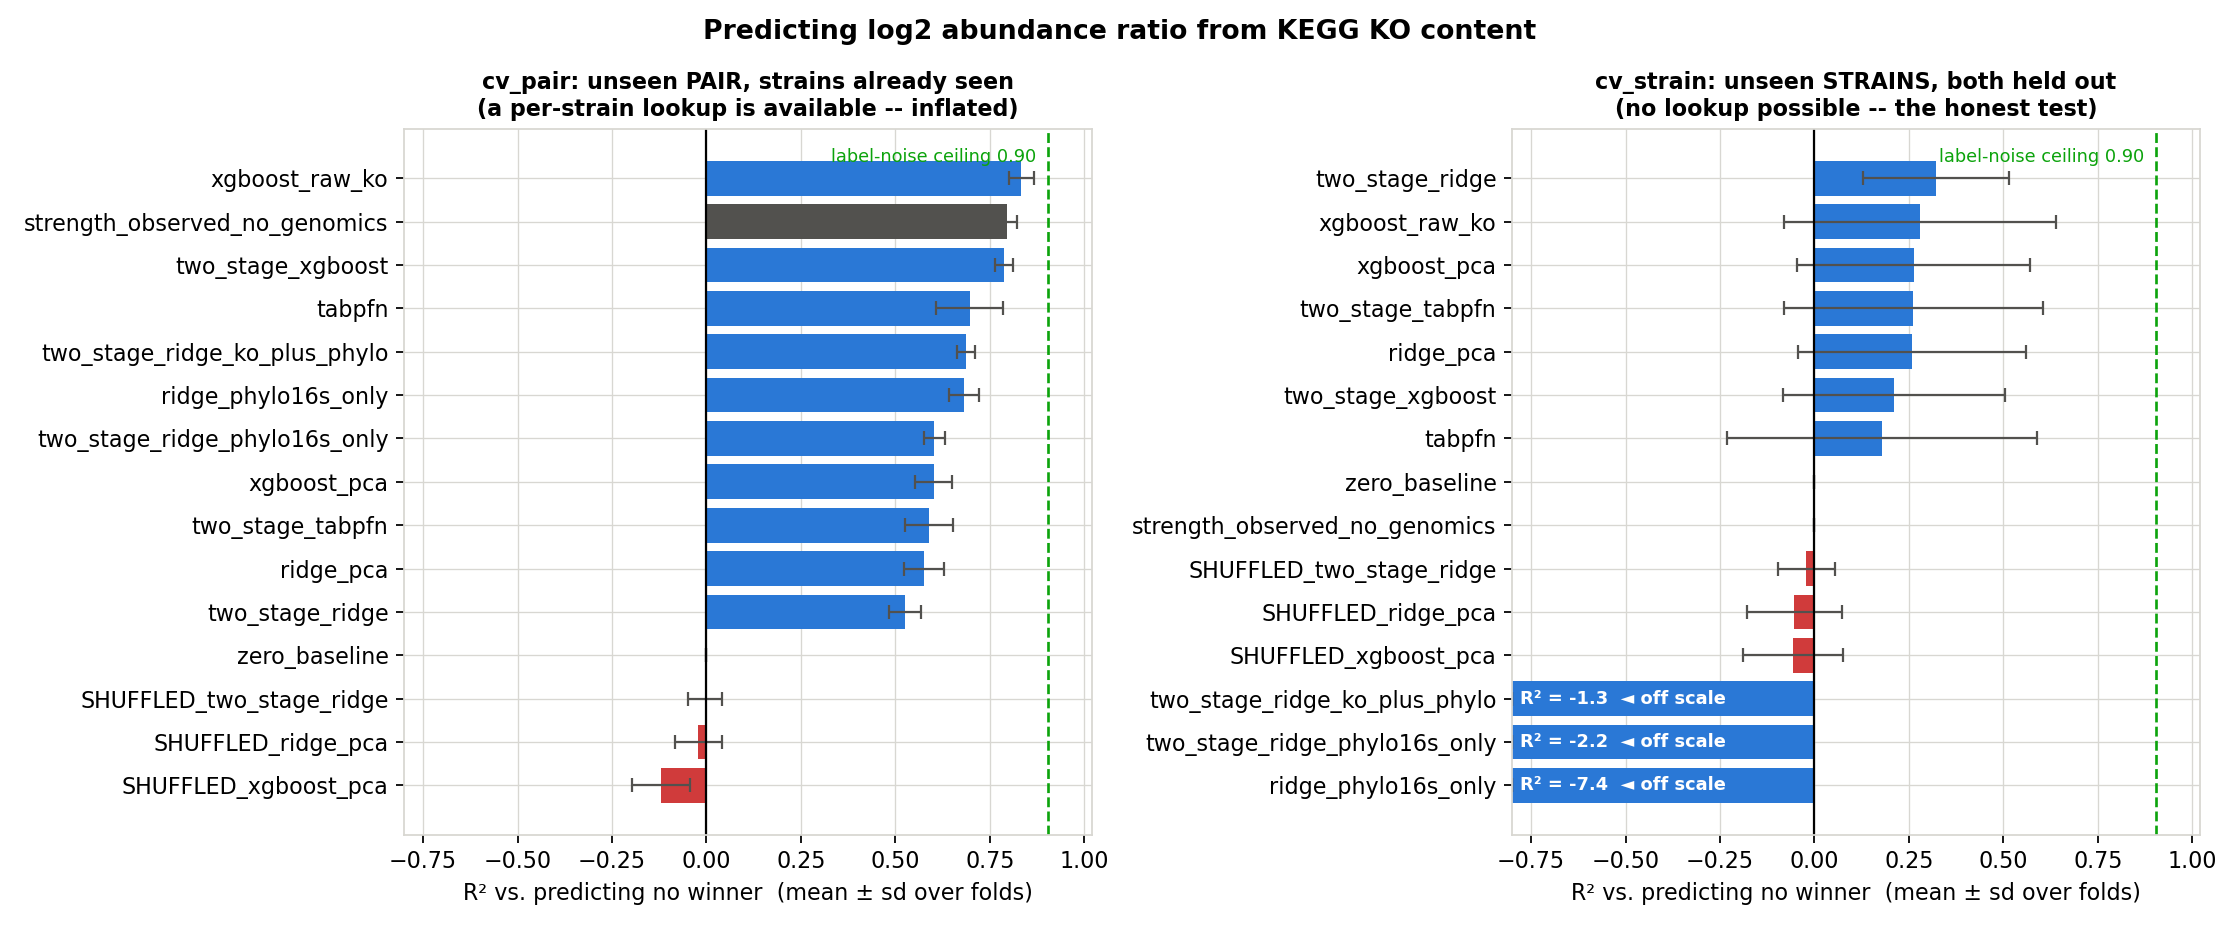

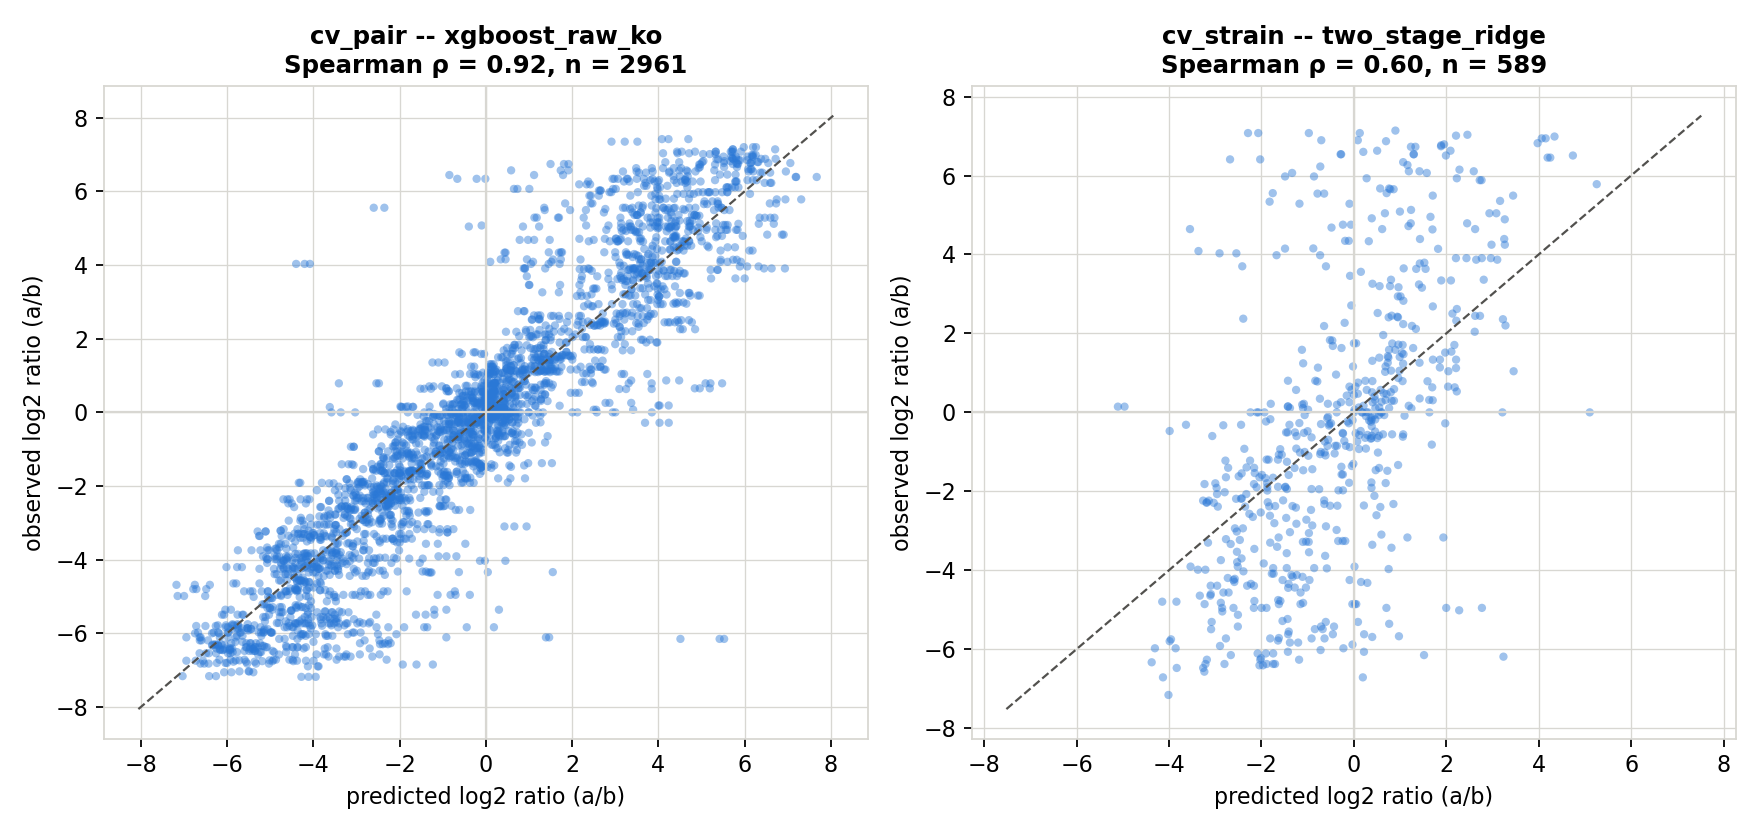

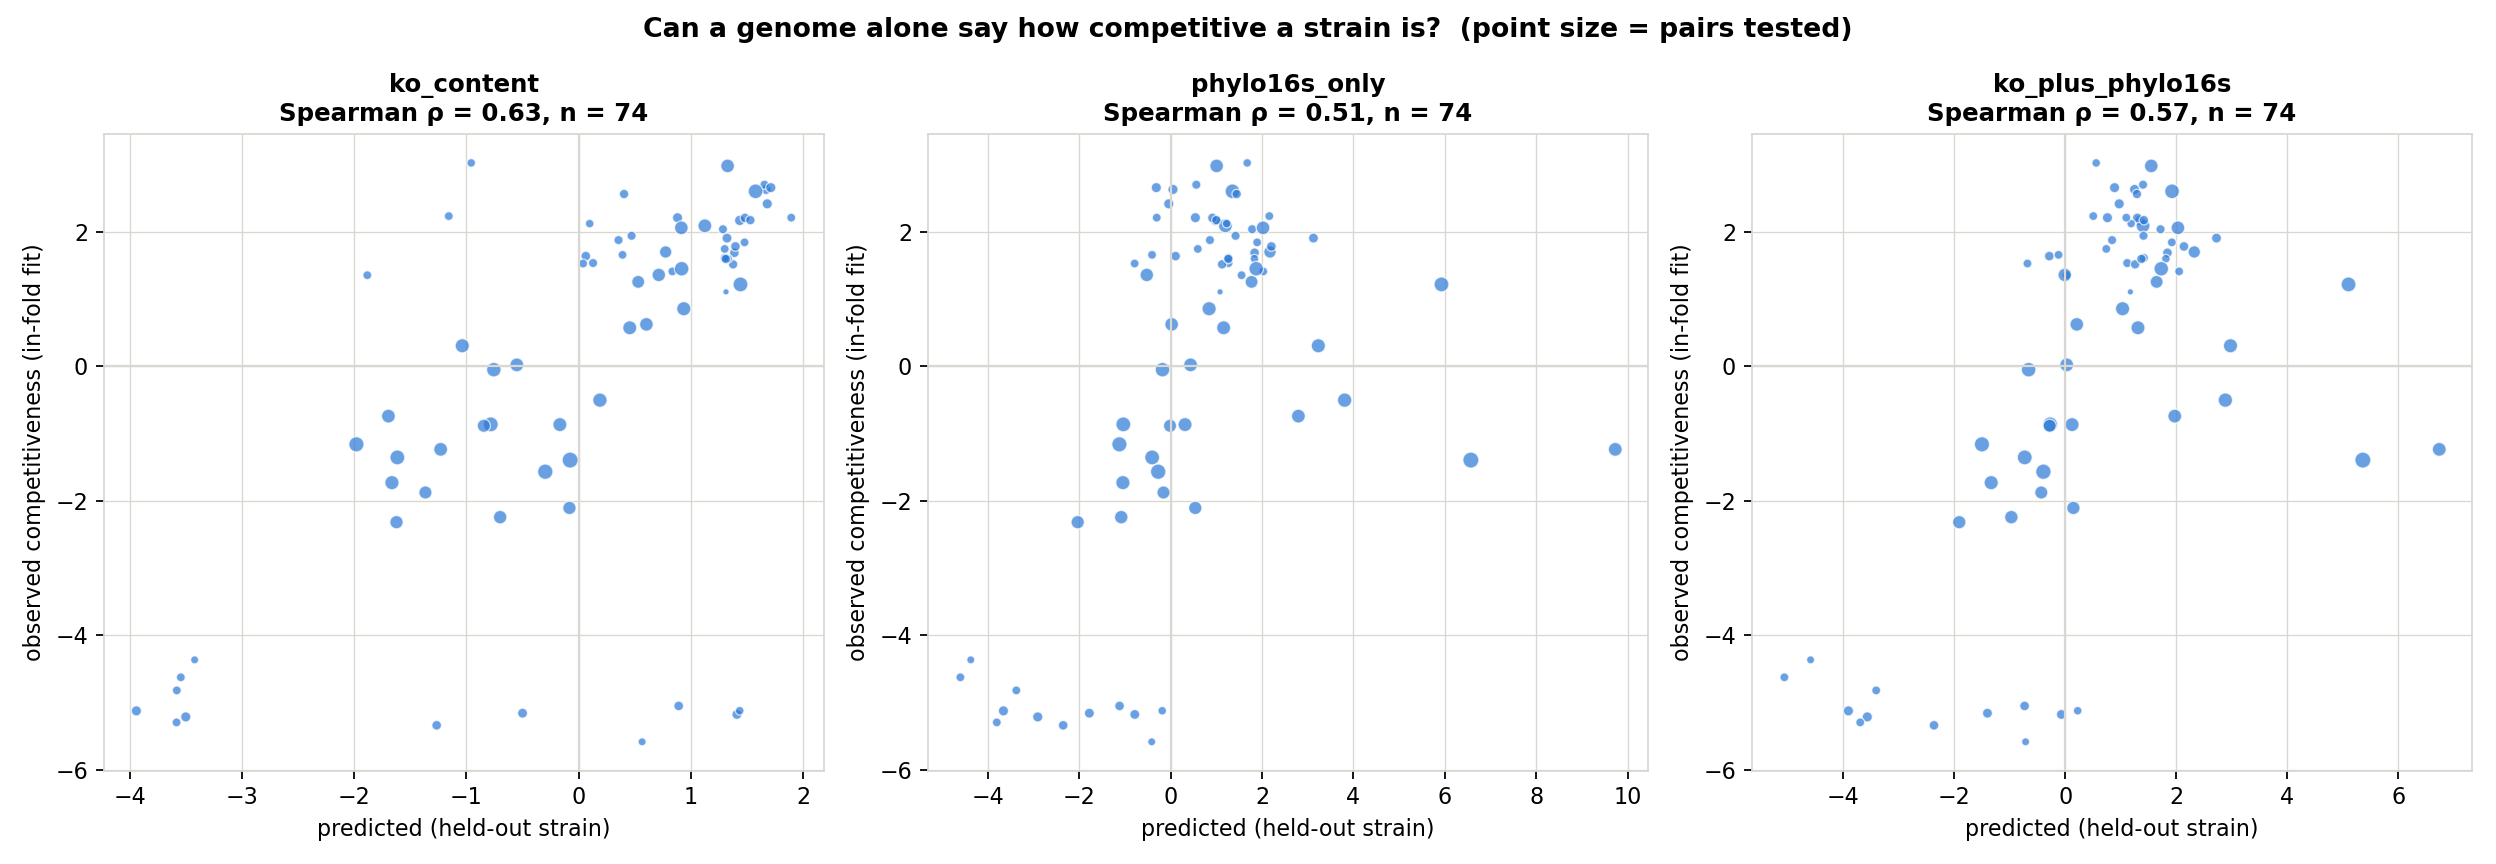

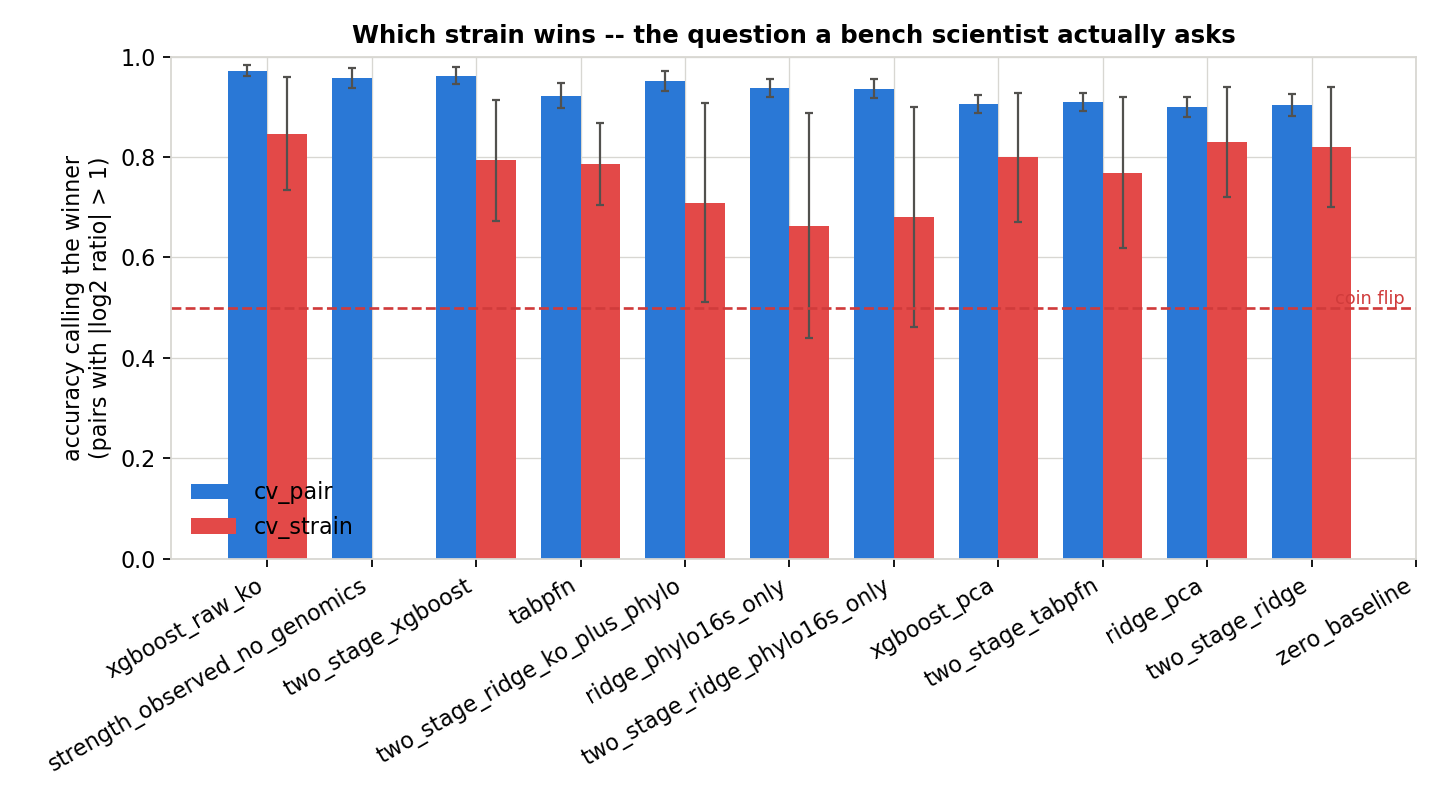

In [8]:
figs = gm.make_all_figures(gcfg, summ_df, fold_df, pair_df, sdf, ceiling)
for f in figs:
    display(Image(filename=str(gcfg.fig_dir / f)))

## 7. Where this leaves things

See `outputs/` for every table behind the numbers above. The honest summary lives in the
`cv_strain` rows and in §5 — `cv_pair` is reported for completeness and should not be quoted as
evidence that genomes predict interactions.

Natural next steps, roughly in order of expected value:

1. **More genomes, not more pairs.** Every ceiling here is set by n = 74 strains. Additional
   pairs among the same strains would sharpen `cv_pair` and barely move `cv_strain`.
2. **Recover 20260721.** It is ~2100 more labelled pairs sitting idle behind one missing
   source-plate mapping. If the plate its wells refer to can be identified, re-run
   `validate_strain_join` on it — the test is already written and takes seconds.
3. **Other annotation schemes.** `KEGG_Module`, `CAZy`, `BiGG`, `PFAMs`, `panx` share the strain
   axis; swapping `GenomicMLConfig.feature_table` is a one-line change. BiGG in particular
   supports a genuine metabolic-complementarity feature rather than a generic overlap score.
4. **The residual is the interesting part.** `relative_abundance` showed the network is ~83% a
   dominance hierarchy; the two-stage model deliberately encodes that. The pair-specific
   *upsets* are what a hierarchy cannot explain, and are where genuinely interaction-level
   biology (antagonism, cross-feeding) would have to show up.